# CZNR on IonQ Hardware

*Reaching Breakeven with CZNR* ran CZNR with the corrections applied inside the circuit, using mid-circuit measurement and feedforward. Real trapped-ion hardware of the kind we target here does not offer mid-circuit measurement, so this notebook uses the equivalent approach that the hardware experiment of Tham and Delfosse (arXiv:2504.13356) actually uses: run the circuit to the end, measure every qubit once, and apply the restarts and Pauli corrections afterwards in classical post-processing.

### What this notebook does

1. Builds the CZNR circuit once in Qiskit, parametrized by the number of qubits per register, and draws it at three qubits so the structure is visible.
2. Sets up the post-processing correction that replaces the in-circuit feedforward of the previous notebook.
3. Prepares the qBraid to IonQ Forte submission, gated behind a flag, with the steps that need a live account marked clearly.
4. Performs the progressive stabilizer-ignoring analysis on hardware results, when a hardware run is available.

The circuit and its diagram use Qiskit; the post-processing correction uses [Stim](https://github.com/quantumlib/Stim)'s Clifford tableaus.

## The CZNR circuit

The experiment runs the Clifford $C^2$, which uses two resource graph states. The data starts on the input register and is passed through the two resources in turn. 

The protocol itself, and its origin in the graph-state formulation of CliNR, is developed in the previous notebook, *Notebook 3 - Reaching Breakeven with CZNR*.

### In-circuit feedforward vs. measure-at-the-end

Notebook 3 simulated a **dynamic** circuit: each resource is checked with a mid-circuit measurement, and the teleportation byproduct is corrected **inside the circuit** by feedforward, conditioned on measurements taken while the circuit is still running.

Forte 1 hardware does not offer mid-circuit measurement or feedforward capabilities currently. But we can adapt the CliNR protocol's verification and corrections to work in post-processing. 

So here every qubit is measured **once, at the very end**. Everything the feedforward used to do is reconstructed **classically, after the run**, from the single final bitstring:

- the **verification bits** decide, in software, whether each shot is kept or discarded (a restart);
- the **teleportation byproduct** is undone by applying the Pauli correction $Q$ to the recorded output bits.

## Setup

In [1]:
#%pip install stim numpy matplotlib qiskit pylatexenc qbraid --quiet

import stim
import numpy as np
import matplotlib.pyplot as plt

## Building blocks

### State preparation on data qubits

The Clifford is the all-pairs CZ circuit on $N$ qubits, run as $C^2$. We fix $N=9$ for the experiment, define the register offsets (input and the two resources), a random single-qubit input preparation `Cprep`, and helpers to apply it.

In [2]:
N = 9                                # data qubits per register
R_in, R_res1, R_res2 = 0, N, 2 * N   # register offsets: input, resource 1, resource 2

def C_on(offset, n):
    """All-pairs controlled-Z on qubits offset..offset+n-1 (the graph-state circuit)."""
    c = stim.Circuit()
    for i in range(n):
        for j in range(i + 1, n):                    # every pair i < j
            c.append('CZ', [offset + i, offset + j]) # one CZ per graph edge
    return c

def make_Cprep(n, seed):
    """A random single-qubit Clifford layer, as per-qubit gate lists from {H, S, S_DAG}."""
    rng = np.random.default_rng(seed)
    # per qubit: draw 3 gates from {H, S, S_DAG, I, I}, drop the I's -> a random 0-3 gate layer
    return [[g for g in rng.choice(['H', 'S', 'S_DAG', 'I', 'I'], size=3) if g != 'I']
            for _ in range(n)]

def apply_Cprep(c, ops, offset, inverse=False):
    """Apply the Cprep layer (or its inverse) to qubits offset..offset+n-1."""
    for q, layer in enumerate(ops):
        for g in (layer[::-1] if inverse else layer):   # inverse: apply in reverse order ...
            c.append({'H': 'H', 'S': 'S_DAG', 'S_DAG': 'S'}[g] if inverse else g, [offset + q])   # ... and swap S <-> S_DAG

# The single input preparation used throughout the experiment (N-qubit version).
Cprep = make_Cprep(N, seed=5)


### Verification stabilizers

We use the same two families of graph-state stabilizers as the previous notebook: low-weight $Y_i Y_j$, and high-weight $X_i \prod_{j \ne i} Z_j$ on every other qubit. A stabilizer chosen on the first resource is also measured on the second resource, shifted onto its qubits.

In [3]:
def lowweight_stab(i, j, offset, n=N):
    """Low-weight stabilizer Y_i Y_j of the resource at the given offset (n qubits per register)."""
    p = stim.PauliString(3 * n); p[offset + i] = 2; p[offset + j] = 2
    return p

def highweight_stab(i, offset, n=N):
    """High-weight stabilizer X_i * product_{j != i} Z_j of the resource at the offset."""
    p = stim.PauliString(3 * n); p[offset + i] = 1
    for j in range(n):
        if j != i: p[offset + j] = 3
    return p

def shift_to_res2(stab, n=N):
    """Move a stabilizer defined on resource 1 onto resource 2 (shift indices by n)."""
    xs, zs = stab.to_numpy(); p = stim.PauliString(3 * n)
    for q in range(len(xs)):
        if xs[q] or zs[q]:
            p[q + n] = 2 if (xs[q] and zs[q]) else (1 if xs[q] else 3)
    return p

## Build CZNR circuit

We write this as a single function, `build_cznr(n, ...)`, parametrized by the number of qubits per register. It is drawn below at $n = 3$ with one stabilizer per resource so the wiring is legible, and the *same* function is submitted at $n = 9$, the version used in the experiment.

In [4]:
def build_cznr(n, Cprep, stabs_res1, ancillas, draw=False):
    """Build the C-squared CZNR circuit as a Qiskit QuantumCircuit.

    Single source of truth for the circuit: drawn below at n = 3 for legibility and
    submitted to hardware at n = 9. No measurement gates are included, because IonQ
    through qBraid measures every qubit at the end automatically. With draw=True,
    stage barriers and a final measurement are added for the diagram only; they do
    not change the submitted circuit.

    Gate set: IonQ's supported gate set has cx but not cz, so for submission
    (draw=False) each cz is emitted as its h.cx.h decomposition and each cy as its
    sdg.cx.s decomposition. With draw=True the compact cz/cy gates are used instead,
    for a legible diagram. The two are logically identical (cz = H_b CX H_b), so the
    picture still faithfully shows the submitted circuit.

    n            qubits per register (input, resource 1, resource 2).
    Cprep        per-qubit input-preparation layer from make_Cprep(n, ...).
    stabs_res1   stabilizers checked on resource 1 (PauliStrings over 3n qubits);
                 the same ones, shifted, are checked on resource 2.
    ancillas     one qubit per check (2 * len(stabs_res1) total).

    Returns the QuantumCircuit.
    """
    from qiskit import QuantumCircuit
    R_in, R_res1, R_res2 = 0, n, 2 * n          # register offsets: input, resource 1, resource 2
    n_stab = len(stabs_res1)                    # number of checks per resource register
    total_qubits = 3 * n + 2 * n_stab           # 3 registers of n + one ancilla per check (2 per stabilizer)
    qc = QuantumCircuit(total_qubits)

    def add_cz(a, b):
        """Compact cz for the diagram; h.cx.h decomposition for IonQ submission."""
        if draw:
            qc.cz(a, b)
        else:
            qc.h(b); qc.cx(a, b); qc.h(b)      # cz = H_b CX H_b

    def add_cy(a, b):
        """Compact cy for the diagram; sdg.cx.s decomposition for IonQ submission."""
        if draw:
            qc.cy(a, b)
        else:
            qc.sdg(b); qc.cx(a, b); qc.s(b)    # cy = S_b CX S_b^dagger

    def apply_prep(offset, inverse=False):
        """Apply the Cprep layer (or its inverse) with Qiskit gates."""
        for q, layer in enumerate(Cprep):
            for g in (layer[::-1] if inverse else layer):                       # inverse: reverse order ...
                gate = {'H': 'H', 'S': 'S_DAG', 'S_DAG': 'S'}[g] if inverse else g   # ... and swap S <-> S_DAG
                if   gate == 'H':     qc.h(offset + q)
                elif gate == 'S':     qc.s(offset + q)
                elif gate == 'S_DAG': qc.sdg(offset + q)

    def verify(stab, a):
        """Read one stabilizer onto ancilla a, left idle (no measurement here)."""
        qc.h(a)                              # ancilla into |+>
        xs, zs = stab.to_numpy()             # X-part and Z-part bits of the stabilizer
        for q in range(3 * n):               # controlled Pauli per non-identity factor
            if   xs[q] and zs[q]: add_cy(a, q)   # Y factor
            elif xs[q]:           qc.cx(a, q)    # X factor
            elif zs[q]:           add_cz(a, q)   # Z factor
        qc.h(a)                              # back to Z basis; read out at the end, not here

    # 1. Input preparation and the two resource graph states (H then all-pairs CZ).
    apply_prep(R_in)                             # input state on the input register
    for i in range(n): qc.h(R_res1 + i)          # |+>^n on resource 1 ...
    for i in range(n):
        for j in range(i + 1, n): add_cz(R_res1 + i, R_res1 + j)   # ... then all-pairs CZ -> graph state
    for i in range(n): qc.h(R_res2 + i)          # same on resource 2
    for i in range(n):
        for j in range(i + 1, n): add_cz(R_res2 + i, R_res2 + j)
    if draw: qc.barrier()

    # 2. Verify resource 1, then apply C by coupling resource 1 into the input.
    for k in range(n_stab): verify(stabs_res1[k], ancillas[k])
    if draw: qc.barrier()
    for i in range(n): qc.cx(R_res1 + i, R_in + i)      # couple resource 1 into the input (injection CNOTs)
    if draw: qc.barrier()

    # 3. Verify resource 2 (shifted stabilizers), then apply C again
    #    (output lands on resource 2 = C squared applied to the input).
    for k in range(n_stab): verify(shift_to_res2(stabs_res1[k], n), ancillas[n_stab + k])
    if draw: qc.barrier()
    for i in range(n): qc.cx(R_res2 + i, R_res1 + i)    # couple resource 2 into resource 1
    if draw: qc.barrier()

    # 4. Undo the input preparation on resource 2, which now holds C^2 Cprep|0>.
    apply_prep(R_res2, inverse=True)

    if draw:
        qc.barrier(); qc.measure_all()   # shown for orientation only; not submitted
    return qc

### Drawn on three qubits

The diagram below shows `build_cznr` at three qubits per register with a single low-weight stabilizer per resource, so the five stages stay legible. The barriers separate the stages, and the final measurement layer is included for orientation only — it is omitted from the circuit actually submitted, since IonQ measures every qubit automatically.

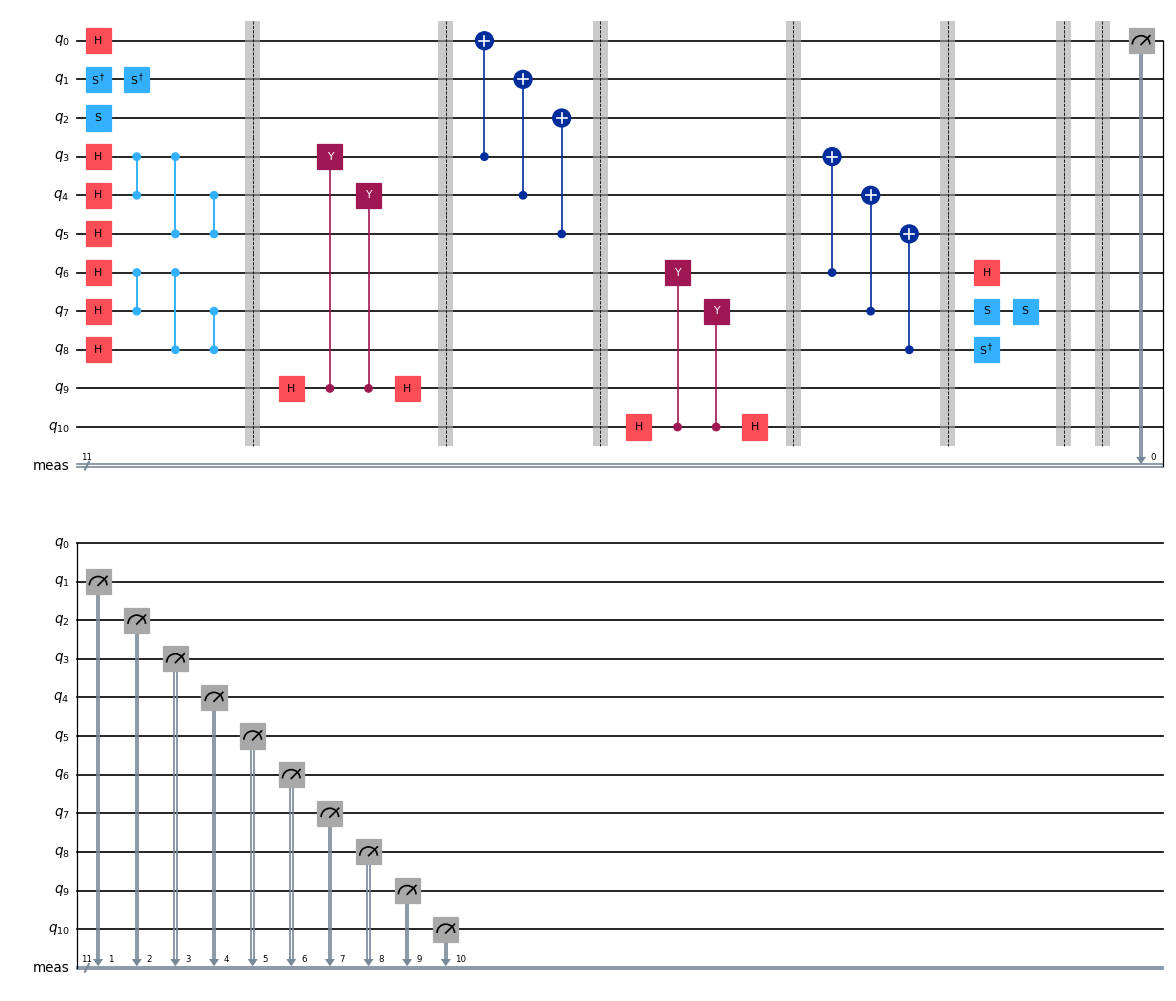

In [5]:
# Draw the exact circuit that gets submitted, at n = 3 with one stabilizer per resource.
n_draw = 3
Cprep_draw = make_Cprep(n_draw, seed=5)
stabs_draw = [lowweight_stab(0, 1, offset=n_draw, n=n_draw)]   # Y_0 Y_1 on resource 1
ancillas_draw = [3 * n_draw + k for k in range(2 * len(stabs_draw))]

qc_draw = build_cznr(n_draw, Cprep_draw, stabs_draw, ancillas_draw, draw=True)
qc_draw.draw(output='mpl', fold=28, scale=0.6)

## The post-processing correction

After the circuit runs, each shot gives three n-bit strings, `b0` from the input register, `b1` from the first resource, and `b2` from the second resource, plus the verification bits. The verification bits decide whether the shot is kept: any non-zero verification bit means a fault was detected and the shot is discarded (a restart). The discarded fraction estimates the restart rate.

For a kept shot, the teleportation byproducts are corrected classically. The correction $Q$ is written compactly as

$$Q = C_{\text{prep}} \, C \, X^{\vec{b}_1 \oplus \vec{b}_0} \, C \, C_{\text{prep}}^{\dagger} = X^{\vec{x}} Z^{\vec{z}}.$$

In [6]:
def make_correction(Cprep, n=N):
    """Return a function corr_x(b0, b1) -> x, the X-part of the post-processing correction,
    for the given input preparation. The output bitstring is then b2 XOR x.
    n is the number of qubits per register (defaults to the experiment's N)."""
    C_tableau = stim.Tableau.from_circuit(C_on(0, n))   # acts on one n-qubit block
    prep_circ = stim.Circuit(); apply_Cprep(prep_circ, Cprep, 0)
    P_tableau = stim.Tableau.from_circuit(prep_circ)


    def conj_X(i):
        """C X_i C^dagger for the all-pairs CZ circuit: X on i, Z on every other qubit."""
        p = stim.PauliString(n); p[i] = 1
        for j in range(n):
            if j != i: p[j] = 3
        return p


    def corr_x(b0, b1):
        total = stim.PauliString(n)
        # b0 byproduct passes through the second C: conjugate each term by C
        for i in range(n):
            if b0[i]: total = total * C_tableau(conj_X(i))
        # b1 byproduct is created directly on the output
        for i in range(n):
            if b1[i]: total = total * conj_X(i)
        # both are then referred back through the input preparation
        total = P_tableau.inverse()(total)
        xs, zs = total.to_numpy()
        return np.array([1 if xs[q] else 0 for q in range(n)], dtype=int)

    return corr_x

In [7]:
def decode_and_correct(counts, Cprep, n_verify, n=N):
    """Apply the post-processing correction to returned counts.

    Each key is a binary string over the 3n+n_verify measured qubits. We parse it as a
    fixed-width integer -- qBraid strips leading zeros, so a key can be shorter than the
    full width, and integer parsing reads the missing high bits as 0 (no IndexError). We
    then read off b0 (input), b1 (resource 1), b2 (resource 2), and the verification bits.
    n is the number of qubits per register. Returns (logical_error, restart_rate)."""
    corr_x = make_correction(Cprep, n)                 # closure: (b0, b1) -> X-correction bitstring
    total_qubits = 3 * n + n_verify                    # three registers of n, plus the verification bits

    def key_to_bits(key):
        # Parse the binary key as an integer, then read out one bit per measured qubit.
        val = int(key, 2)
        return [(val >> q) & 1 for q in range(total_qubits)]

    # Qubit-index ranges for each block of the measured register.
    in_q  = list(range(0, n)); r1_q = list(range(n, 2 * n)); r2_q = list(range(2 * n, 3 * n))
    ver_q = list(range(3 * n, 3 * n + n_verify))       # verification (ancilla) outcomes
    n_fail = n_accept = n_zero = 0
    total = sum(counts.values())                       # total shots (counts are aggregated per key)

    for key, count in counts.items():
        bits = key_to_bits(key)
        if any(bits[q] for q in ver_q):           # fault detected -> discard (restart)
            n_fail += count; continue
        # Split the kept shot into the three register bitstrings.
        b0 = np.array([bits[q] for q in in_q], dtype=int)   # input register outcomes
        b1 = np.array([bits[q] for q in r1_q], dtype=int)   # resource 1 outcomes
        b2 = np.array([bits[q] for q in r2_q], dtype=int)   # resource 2 (carries the output)
        x = corr_x(b0, b1)                            # X-part of the teleportation correction
        n_accept += count
        if not (b2 ^ x).any():                       # corrected output b2 XOR x all zeros -> success
            n_zero += count

    # Logical error = fraction of accepted shots whose corrected output is not all zeros.
    logical_error = 1 - n_zero / n_accept if n_accept else 1.0
    return logical_error, n_fail / total             # (logical error, restart/discard rate)

## Test on the free simulator

Before spending anything on hardware, we validate the whole submission path — the `cx`-decomposed circuit *and* the post-processing decoder — on the free `ionq:ionq:sim:simulator`, at a small $n = 2$. 

Noiseless, the corrected logical error must be exactly zero — that confirms the gate decompositions, the readback, and the decoder all agree with the circuit. Each family is then run once more under IonQ's `aria-1` noise model.

In [8]:
from qbraid import QbraidProvider

def sim_check(n, family, shots=800, noise_model=None):
    """Run the cx-decomposed CZNR circuit + decoder on the free ionq:ionq simulator.
    family 'high-weight' exercises the cz->cx path; 'low-weight' the cy path.
    Returns (logical_error, restart)."""
    Cp = make_Cprep(n, seed=5)                          # fixed random input preparation
    # One verification stabilizer on resource 1, picked to exercise a specific decomposition path.
    if family == 'high-weight':
        stabs = [highweight_stab(0, n, n=n)]            # X_0 * Z... on resource 1  (Z couplings -> cz->cx)
    else:
        stabs = [lowweight_stab(0, 1, offset=n, n=n)]   # Y_0 Y_1 on resource 1     (Y coupling  -> cy path)
    anc = [3 * n + k for k in range(2 * len(stabs))]    # one ancilla per check (both resources)
    n_verify = 2 * len(stabs)                           # total verification measurements
    qc = build_cznr(n, Cp, stabs, anc)   # draw=False -> cx / cy decomposed

    # Submit to the free IonQ simulator through qBraid and block for the result.
    device = QbraidProvider().get_device('ionq:ionq:sim:simulator')
    run_kwargs = {'shots': shots}
    if noise_model is not None:
        # Optional IonQ device-noise model (e.g. 'aria-1'); fixed seed for reproducibility.
        run_kwargs['runtime_options'] = {'noise': {'model': noise_model, 'seed': 42}}
    job = device.run(qc, **run_kwargs)
    job.wait_for_final_state()
    counts = job.result().data.measurement_counts       # integer-keyed histogram of outcomes
    return decode_and_correct(counts, Cp, n_verify, n=n)

# Run both families noiseless (must decode to exactly 0), then again under the aria-1 noise model.
print(f'{"family":12} {"noise":8} {"logical error":>13} {"restart":>8}')
print('-' * 45)
for family in ['high-weight', 'low-weight']:
    err0, r0 = sim_check(2, family, noise_model=None)
    print(f'{family:12} {"none":8} {err0:>13.4f} {r0:>8.3f}')
    assert err0 == 0.0, f'{family}: noiseless logical error must be 0, got {err0}'   # correctness gate
    try:
        errn, rn = sim_check(2, family, noise_model='aria-1')
        print(f'{family:12} {"aria-1":8} {errn:>13.4f} {rn:>8.3f}')
    except Exception as e:
        # aria-1 may be unavailable in some environments; report and continue rather than fail.
        print(f'{family:12} {"aria-1":8}  (skipped: {type(e).__name__})')
print('\nNoiseless decode is exact (0.0) for both families: gate decomposition + readback are correct.')

family       noise    logical error  restart
---------------------------------------------
high-weight  none            0.0000    0.000
high-weight  aria-1          0.0367    0.046
low-weight   none            0.0000    0.000
low-weight   aria-1          0.0595    0.034

Noiseless decode is exact (0.0) for both families: gate decomposition + readback are correct.


## Running on IonQ Forte through qBraid

Submission is gated by a single flag, `RUN_ON_HARDWARE` (default `False`, so the notebook is safe to run end to end). Set `RUN_ON_HARDWARE = True` only with a qBraid account that has IonQ access and credits; it submits the $n = 9$ circuit to IonQ Forte (`aws:ionq:qpu:forte-1`). The full $n = 9$ (33-qubit) circuit is too large for the free simulator, so the free-simulator validation is the $n = 2$ smoke test above.

### A note on credits

A run on IonQ Forte via qBraid uses qBraid credits. The IonQ Forte-1 accessed through AWS charges **30 credits per task + 8 credits per shot** (Example: 1024 shots = ~8222 credits). Always validate on the free simulator (the cell above) before submitting to hardware. More pricing details: [docs.qbraid.com/v2/home/pricing](https://docs.qbraid.com/v2/home/pricing).

In [9]:
# --- Submission control ---
# RUN_ON_HARDWARE gates whether the n = 9 circuit is sent to IonQ Forte (paid). Default False, so the
# notebook is safe to run end to end. The free-simulator validation is the n = 2 smoke test
# above; the full n = 9 (33-qubit) circuit is too large for the free simulator, so this cell
# targets hardware only.
RUN_ON_HARDWARE = False
IONQ_DEVICE = 'aws:ionq:qpu:forte-1'   # paid IonQ Forte; the AWS path is strict (cx, not cz)
HARDWARE_SHOTS = 100

In [10]:
def submit_to_ionq(Cprep, stabs_res1, ancillas, device_id, shots):
    """Build the CZNR submission circuit and submit it through qBraid's runtime.

    Returns the job WITHOUT blocking, so the job id is captured before any
    wait -- an interrupted wait then never orphans the job. Retrieve results separately with
    job.wait_for_final_state() and job.result().

    device_id    'aws:ionq:qpu:forte-1' (paid Forte).
    """
    from qbraid import QbraidProvider

    # Same builder drawn above, at n = N. draw=False emits cx (IonQ's set has no cz).
    qc = build_cznr(N, Cprep, stabs_res1, ancillas)

    provider = QbraidProvider()
    device = provider.get_device(device_id)             # paid Forte QPU
    job = device.run(qc, shots=shots)                   # non-blocking submit
    print(f'Job submitted to {device_id}. Job ID: {job.id}')   # capture the id before any wait
    return job

In [11]:
# Build the n = 9 submission circuit (high-weight, r = 3) and submit it -- no blocking.
hw_centres = [0, 3, 7]
hw_stabs = [highweight_stab(i, R_res1) for i in hw_centres]
hw_ancillas = [3 * N + k for k in range(2 * len(hw_stabs))]
hw_nverify = 2 * len(hw_stabs)

if RUN_ON_HARDWARE:
    hw_job = submit_to_ionq(Cprep, hw_stabs, hw_ancillas, IONQ_DEVICE, HARDWARE_SHOTS)
    JOB_ID = hw_job.id
    print(f'Saved JOB_ID = {JOB_ID}')
    print('Retrieve results in the next cell; the job id above survives an interrupted wait.')
else:
    hw_job, JOB_ID = None, None
    print(f'Submission off (RUN_ON_HARDWARE = False). Set RUN_ON_HARDWARE = True to submit to {IONQ_DEVICE}.')

Submission off (RUN_ON_HARDWARE = False). Set RUN_ON_HARDWARE = True to submit to aws:ionq:qpu:forte-1.


In [12]:
# Retrieve and decode. Run this after the job above completes.
# Interrupting the wait here is safe: the job keeps running and JOB_ID (printed above) still
# identifies it, so you can re-run this cell -- or, in a fresh kernel, reload the job from
# JOB_ID via the Jobs panel / QbraidProvider before decoding.
if hw_job is not None:
    hw_job.wait_for_final_state()
    counts = hw_job.result().data.measurement_counts
    hw_error, hw_restart = decode_and_correct(counts, Cprep, hw_nverify)
    print(f'CZNR logical error on {IONQ_DEVICE}: {hw_error:.5f}  (restart {hw_restart:.3f})')
else:
    counts = None
    print('No job to retrieve. Set RUN_ON_HARDWARE = True, run the submission cell, then this one.')

No job to retrieve. Set RUN_ON_HARDWARE = True, run the submission cell, then this one.


### Retrieve a job by ID

If you submitted in one session and the kernel is gone, come back later, run the **definition cells above** (Setup, Building blocks, stabilizer helpers, `build_cznr`, `make_correction`, `decode_and_correct`). 

IMPORTANT NOTE: keep `RUN_ON_HARDWARE = False` (the default) so even if you re-run the submission cell a new paid job is not launched. 

Then paste the job id from the qBraid **Jobs panel** into the cell below.

In [ ]:
from qbraid.runtime.native import QbraidJob

JOB_ID = "PASTE JOB ID HERE"                     # paste a job id from the qBraid Jobs panel
hw_nverify = 6                                    # 6 = 2 x 3 stabilizers

counts = None
if not JOB_ID or JOB_ID == "PASTE JOB ID HERE":
    print('No job id set. Paste a real job id above (from the qBraid Jobs panel), then re-run this cell.')
else:
    try:
        job = QbraidJob(JOB_ID)                   # recover the job object straight from its id
        counts = job.result().data.measurement_counts
        hw_error, hw_restart = decode_and_correct(counts, Cprep, hw_nverify)
        print(f'Retrieved {JOB_ID} | status: {job.status()}')
        print(f'CZNR logical error {hw_error:.5f}   restart {hw_restart:.3f}')
    except Exception as e:
        counts = None
        print(f'Could not retrieve job {JOB_ID!r}: {type(e).__name__}: {e}')
        print('Check the id is correct and that this qBraid account owns the job.')

## Progressive stabilizer ignoring

This analysis reproduces the paper's demonstration that the verification is doing real work, and it runs on hardware results. 

Starting from a run with three stabilizers, we recompute the logical error rate while ignoring some of the stabilizer outcomes, that is, accepting shots that those checks would have rejected. 

As more stabilizers are ignored, fewer shots are discarded, so the acceptance rate rises, and the logical error rate gets worse because faults that would have been caught are now kept. A logical error rate that climbs as checks are dropped is direct evidence that the checks were removing real errors.

 ignored | logical error | acceptance
--------------------------------------
       0 |       0.66667 |      0.150
       1 |       0.77273 |      0.220
       2 |       0.81481 |      0.270
       3 |       0.86111 |      0.360
       4 |       0.86364 |      0.440
       5 |       0.87931 |      0.580
       6 |       0.91000 |      1.000


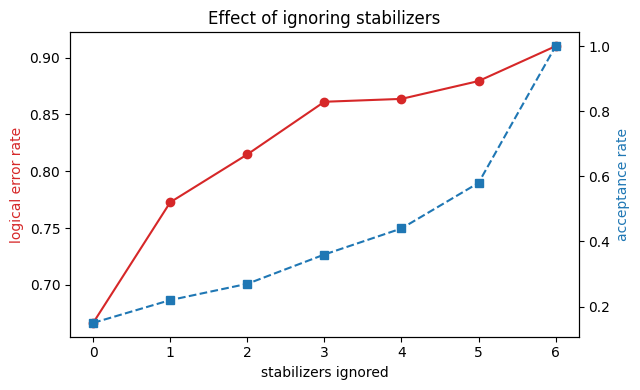

In [14]:
def progressive_ignore(counts, Cprep, n_total_checks, n=N):
    """Recompute logical error and acceptance while ignoring the last k of n_total_checks
    stabilizer measurements, for k = 0..n_total. Returns (k_ignored, logical_error, acceptance)."""
    # Dropping stabilizer checks means accepting shots that would have been rejected.
    # If the logical error rate rises as checks are dropped, the checks were catching
    # real errors -- the signature that verification is doing useful work.
    corr_x = make_correction(Cprep, n)                 # same post-processing X-correction as the decoder
    total_qubits = 3 * n + n_total_checks

    def key_to_bits(key):
        # Parse a count key (binary string) into one bit per measured qubit.
        val = int(key, 2)
        return [(val >> q) & 1 for q in range(total_qubits)]

    # Register qubit ranges, plus the verification outcomes we will progressively ignore.
    in_q = list(range(0, n)); r1_q = list(range(n, 2 * n)); r2_q = list(range(2 * n, 3 * n))
    ver_q = list(range(3 * n, 3 * n + n_total_checks))
    total = sum(counts.values())
    out = []

    for k in range(n_total_checks + 1):
        active = ver_q[:n_total_checks - k]          # enforce all but the last k checks
        n_accept = n_zero = 0
        for key, count in counts.items():
            bits = key_to_bits(key)
            if any(bits[q] for q in active):         # rejected by a still-active check -> skip
                continue
            # Decode the three registers and apply the correction, exactly as in decode_and_correct.
            b0 = np.array([bits[q] for q in in_q], dtype=int)
            b1 = np.array([bits[q] for q in r1_q], dtype=int)
            b2 = np.array([bits[q] for q in r2_q], dtype=int)
            x = corr_x(b0, b1); n_accept += count
            if not (b2 ^ x).any(): n_zero += count    # corrected output all zeros -> no logical error
        # Record (checks ignored, logical error among accepted, acceptance fraction) at this k.
        logical_error = 1 - n_zero / n_accept if n_accept else 1.0
        out.append((k, logical_error, n_accept / total))
    return out

if counts is not None:
    rows = progressive_ignore(counts, Cprep, hw_nverify)
    print(f'{"ignored":>8} | {"logical error":>13} | {"acceptance":>10}')
    print('-' * 38)
    for k, err, acc in rows:
        print(f'{k:>8} | {err:>13.5f} | {acc:>10.3f}')
    # Twin-axis plot: logical error (left, red) and acceptance (right, blue) vs checks ignored.
    ks = [r[0] for r in rows]; errs = [r[1] for r in rows]; accs = [r[2] for r in rows]
    fig, ax1 = plt.subplots(figsize=(6.5, 4))
    ax1.plot(ks, errs, 'o-', color='tab:red'); ax1.set_xlabel('stabilizers ignored')
    ax1.set_ylabel('logical error rate', color='tab:red')
    ax2 = ax1.twinx(); ax2.plot(ks, accs, 's--', color='tab:blue')
    ax2.set_ylabel('acceptance rate', color='tab:blue')
    ax1.set_title('Effect of ignoring stabilizers')
    plt.tight_layout(); plt.show()
else:
    print('No results to analyse. Run the submission section above first.')

## What we have

CZNR by post-processing implements the same protocol as the in-circuit version of *Reaching Breakeven with CZNR*, but defers every correction to classical post-processing. That is what lets it run on hardware with no mid-circuit measurement; the previous notebook's simulations show the deferral costs nothing in logical error rate.

The hardware section submits the same circuit to IonQ Forte through qBraid when enabled, and the progressive stabilizer-ignoring analysis, run on the hardware results, shows the verification removing real errors. Together these reproduce the breakeven demonstration of the experiment.

This is where the present series ends. A natural next step is the noise reduction scheme based on mid-circuit measurements of Brown and collaborators, which uses the measurement capabilities we set aside here.

## References

[1] N. Delfosse and E. Tham, "Clifford Noise Reduction," arXiv:2407.06583 (2024).

[2] E. Tham and N. Delfosse, "Optimized Clifford Noise Reduction: Theory, Simulations and Experiments," *Quantum* **9**, 1829 (2025). [arXiv:2504.13356](https://arxiv.org/abs/2504.13356)